In [3]:
import os
import shutil

# Paths
input_path = '/kaggle/input/cats-and-dogs-mini-dataset/'
output_path = '/kaggle/working/cats_and_dogs_mini/'

# Create the target folder
os.makedirs(output_path, exist_ok=True)

# Move/rename folders to 'cats' and 'dogs'
shutil.copytree(os.path.join(input_path, 'cats_set'), os.path.join(output_path, 'cats'))
shutil.copytree(os.path.join(input_path, 'dogs_set'), os.path.join(output_path, 'dogs'))

print("New folder structure:", os.listdir(output_path))


New folder structure: ['cats', 'dogs']


In [4]:
import os

dataset_path = '/kaggle/input/cats-and-dogs-mini-dataset/'
print("Contents of dataset folder:", os.listdir(dataset_path))

Contents of dataset folder: ['dogs_set', 'cats_set']


In [5]:
import tensorflow as tf
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print("GPU is available:", gpus)
else:
    print("No GPU detected!")


GPU is available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [6]:
# Cell 2 — imports & hyperparameters
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt

# Hyperparameters
IMG_SIZE = (224, 224)
BATCH_SIZE = 16
INITIAL_EPOCHS = 6
FINE_TUNE_EPOCHS = 6
LR_HEAD = 1e-4
LR_FINE = 1e-5
VALIDATION_SPLIT = 0.2
SEED = 42

print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.18.0


In [7]:
# Cell 3 — data generators
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.12,
    height_shift_range=0.12,
    shear_range=0.08,
    zoom_range=0.12,
    horizontal_flip=True,
    validation_split=VALIDATION_SPLIT
)

train_generator = train_datagen.flow_from_directory(
    DATA_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='training',
    seed=SEED
)

val_generator = train_datagen.flow_from_directory(
    DATA_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='validation',
    seed=SEED,
    shuffle=False
)

# Optional: print class indices
print("Class indices:", train_generator.class_indices)


Found 800 images belonging to 2 classes.
Found 200 images belonging to 2 classes.
Class indices: {'cats': 0, 'dogs': 1}


In [8]:
# Cell 4 — build VGG16 feature extraction model
base_model = VGG16(weights='imagenet', include_top=False,
                   input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3))

# Freeze base
base_model.trainable = False

# Add custom head
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.4)(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.3)(x)
outputs = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=outputs)

model.compile(optimizer=Adam(learning_rate=LR_HEAD),
              loss='binary_crossentropy',
              metrics=['accuracy'])

model.summary()


I0000 00:00:1771485000.835403      47 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1771485000.838070      47 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴─────────────

 Total params: 14,846,273 (56.63 MB)

 Trainable params: 131,585 (514.00 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [9]:
# Cell 5 — callbacks
checkpoint = ModelCheckpoint('/kaggle/working/vgg16_cats_dogs_best.h5',
                             monitor='val_accuracy', save_best_only=True, mode='max', verbose=1)

early = EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True)

reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7)

callbacks = [checkpoint, early, reduce_lr]


In [10]:
# Cell 6 — train classifier head
steps_per_epoch = max(1, train_generator.samples // BATCH_SIZE)
validation_steps = max(1, val_generator.samples // BATCH_SIZE)

history_head = model.fit(
    train_generator,
    steps_per_epoch=steps_per_epoch,
    epochs=INITIAL_EPOCHS,
    validation_data=val_generator,
    validation_steps=validation_steps,
    callbacks=callbacks
)


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/6


I0000 00:00:1771485005.634180     123 service.cc:148] XLA service 0x7c42d800f1d0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1771485005.635806     123 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1771485005.635833     123 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1771485006.155142     123 cuda_dnn.cc:529] Loaded cuDNN version 90300


 2/50 ━━━━━━━━━━━━━━━━━━━━ 4s 91ms/step - accuracy: 0.4688 - loss: 0.8246 

I0000 00:00:1771485014.748543     123 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step - accuracy: 0.5138 - loss: 0.7263
Epoch 1: val_accuracy improved from -inf to 0.62500, saving model to /kaggle/working/vgg16_cats_dogs_best.h5


50/50 ━━━━━━━━━━━━━━━━━━━━ 23s 256ms/step - accuracy: 0.5140 - loss: 0.7261 - val_accuracy: 0.6250 - val_loss: 0.6807 - learning_rate: 1.0000e-04
Epoch 2/6
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step - accuracy: 0.5307 - loss: 0.7109
Epoch 2: val_accuracy improved from 0.62500 to 0.66667, saving model to /kaggle/working/vgg16_cats_dogs_best.h5


50/50 ━━━━━━━━━━━━━━━━━━━━ 12s 232ms/step - accuracy: 0.5311 - loss: 0.7107 - val_accuracy: 0.6667 - val_loss: 0.6566 - learning_rate: 1.0000e-04
Epoch 3/6
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 191ms/step - accuracy: 0.5285 - loss: 0.6800
Epoch 3: val_accuracy improved from 0.66667 to 0.75521, saving model to /kaggle/working/vgg16_cats_dogs_best.h5


50/50 ━━━━━━━━━━━━━━━━━━━━ 12s 240ms/step - accuracy: 0.5287 - loss: 0.6800 - val_accuracy: 0.7552 - val_loss: 0.6439 - learning_rate: 1.0000e-04
Epoch 4/6
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step - accuracy: 0.5927 - loss: 0.6805
Epoch 4: val_accuracy improved from 0.75521 to 0.82292, saving model to /kaggle/working/vgg16_cats_dogs_best.h5


50/50 ━━━━━━━━━━━━━━━━━━━━ 12s 243ms/step - accuracy: 0.5931 - loss: 0.6802 - val_accuracy: 0.8229 - val_loss: 0.6179 - learning_rate: 1.0000e-04
Epoch 5/6
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/step - accuracy: 0.6265 - loss: 0.6519
Epoch 5: val_accuracy did not improve from 0.82292
50/50 ━━━━━━━━━━━━━━━━━━━━ 12s 236ms/step - accuracy: 0.6268 - loss: 0.6516 - val_accuracy: 0.6771 - val_loss: 0.6182 - learning_rate: 1.0000e-04
Epoch 6/6
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step - accuracy: 0.6458 - loss: 0.6455
Epoch 6: val_accuracy did not improve from 0.82292
50/50 ━━━━━━━━━━━━━━━━━━━━ 12s 233ms/step - accuracy: 0.6455 - loss: 0.6454 - val_accuracy: 0.8021 - val_loss: 0.5888 - learning_rate: 1.0000e-04


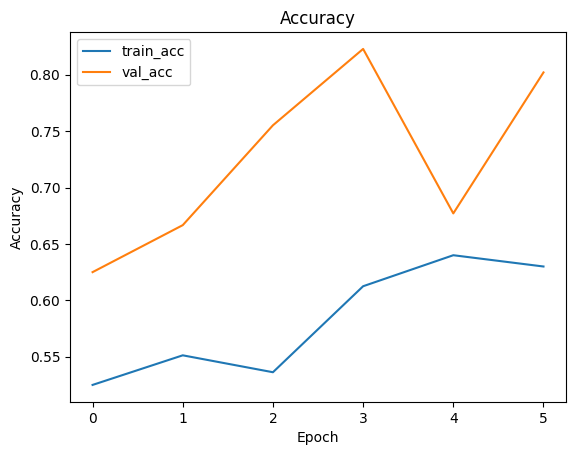

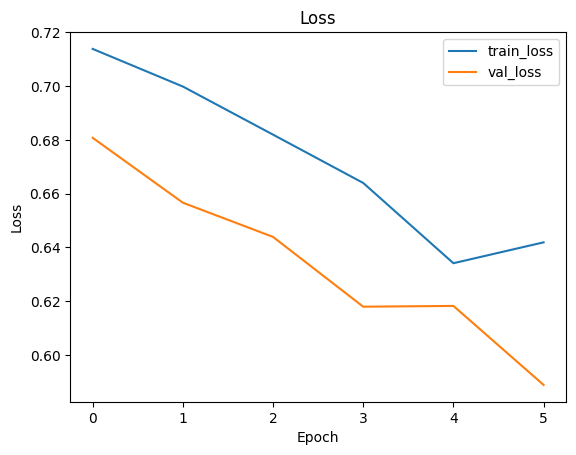

In [11]:
import matplotlib.pyplot as plt

# Accuracy
plt.plot(history_head.history['accuracy'], label='train_acc')
plt.plot(history_head.history['val_accuracy'], label='val_acc')
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

# Loss
plt.plot(history_head.history['loss'], label='train_loss')
plt.plot(history_head.history['val_loss'], label='val_loss')
plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()


In [12]:
for layer in base_model.layers[-4:]:  # unfreeze last 4 layers
    layer.trainable = True

# Recompile and train
model.compile(optimizer=tf.keras.optimizers.Adam(1e-5),
              loss='binary_crossentropy',
              metrics=['accuracy'])

history_finetune = model.fit(
    train_generator,
    steps_per_epoch=steps_per_epoch,
    epochs=5,
    validation_data=val_generator,
    validation_steps=validation_steps,
    callbacks=callbacks
)


Epoch 1/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 186ms/step - accuracy: 0.6666 - loss: 0.5912
Epoch 1: val_accuracy improved from 0.82292 to 0.83333, saving model to /kaggle/working/vgg16_cats_dogs_best.h5


50/50 ━━━━━━━━━━━━━━━━━━━━ 18s 258ms/step - accuracy: 0.6670 - loss: 0.5908 - val_accuracy: 0.8333 - val_loss: 0.4534 - learning_rate: 1.0000e-05
Epoch 2/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 188ms/step - accuracy: 0.7893 - loss: 0.4720
Epoch 2: val_accuracy improved from 0.83333 to 0.88021, saving model to /kaggle/working/vgg16_cats_dogs_best.h5


50/50 ━━━━━━━━━━━━━━━━━━━━ 12s 242ms/step - accuracy: 0.7896 - loss: 0.4715 - val_accuracy: 0.8802 - val_loss: 0.3365 - learning_rate: 1.0000e-05
Epoch 3/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step - accuracy: 0.8515 - loss: 0.3829
Epoch 3: val_accuracy did not improve from 0.88021
50/50 ━━━━━━━━━━━━━━━━━━━━ 12s 240ms/step - accuracy: 0.8517 - loss: 0.3825 - val_accuracy: 0.8802 - val_loss: 0.3234 - learning_rate: 1.0000e-05
Epoch 4/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 190ms/step - accuracy: 0.8709 - loss: 0.3023
Epoch 4: val_accuracy improved from 0.88021 to 0.88542, saving model to /kaggle/working/vgg16_cats_dogs_best.h5


50/50 ━━━━━━━━━━━━━━━━━━━━ 12s 244ms/step - accuracy: 0.8708 - loss: 0.3026 - val_accuracy: 0.8854 - val_loss: 0.2807 - learning_rate: 1.0000e-05
Epoch 5/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 195ms/step - accuracy: 0.9050 - loss: 0.2657
Epoch 5: val_accuracy did not improve from 0.88542
50/50 ━━━━━━━━━━━━━━━━━━━━ 12s 243ms/step - accuracy: 0.9049 - loss: 0.2657 - val_accuracy: 0.8646 - val_loss: 0.3061 - learning_rate: 1.0000e-05


In [13]:
model.save('/kaggle/working/vgg16_cats_dogs_best.keras')


In [14]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# Get predictions
val_generator.reset()
y_pred = model.predict(val_generator, steps=validation_steps, verbose=1)
y_pred_classes = (y_pred > 0.5).astype(int)

# True labels
y_true = val_generator.classes[:len(y_pred_classes)]

# Confusion matrix
print("Confusion Matrix:")
print(confusion_matrix(y_true, y_pred_classes))

# Classification report
print("Classification Report:")
print(classification_report(y_true, y_pred_classes, target_names=list(val_generator.class_indices.keys())))


12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 166ms/step
Confusion Matrix:
[[90 10]
 [ 7 85]]
Classification Report:
              precision    recall  f1-score   support

        cats       0.93      0.90      0.91       100
        dogs       0.89      0.92      0.91        92

    accuracy                           0.91       192
   macro avg       0.91      0.91      0.91       192
weighted avg       0.91      0.91      0.91       192



In [15]:
import os
from tensorflow.keras.preprocessing import image
import numpy as np

# Dataset folders
cats_dir = '/kaggle/working/cats_and_dogs_mini/cats'
dogs_dir = '/kaggle/working/cats_and_dogs_mini/dogs'

# Pick the first image from each folder
cat_img_path = os.path.join(cats_dir, os.listdir(cats_dir)[0])
dog_img_path = os.path.join(dogs_dir, os.listdir(dogs_dir)[0])

# Function to predict
def predict_image(img_path):
    img = image.load_img(img_path, target_size=(224,224))
    img_array = image.img_to_array(img)/255.0
    img_array = np.expand_dims(img_array, axis=0)
    
    prediction = model.predict(img_array)
    if prediction[0][0] > 0.5:
        return f"{os.path.basename(img_path)} → Predicted: Dog"
    else:
        return f"{os.path.basename(img_path)} → Predicted: Cat"

# Test
print(predict_image(cat_img_path))
print(predict_image(dog_img_path))




1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
cat.4385.jpg → Predicted: Cat
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
dog.4324.jpg → Predicted: Cat


In [16]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# Reset validation generator
val_generator.reset()

# Predictions
y_pred = model.predict(val_generator, steps=validation_steps, verbose=1)
y_pred_classes = (y_pred > 0.5).astype(int)

# True labels
y_true = val_generator.classes[:len(y_pred_classes)]

# Confusion matrix
print("Confusion Matrix:")
print(confusion_matrix(y_true, y_pred_classes))

# Classification report
print("Classification Report:")
print(classification_report(y_true, y_pred_classes, target_names=list(val_generator.class_indices.keys())))


12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 181ms/step
Confusion Matrix:
[[90 10]
 [ 7 85]]
Classification Report:
              precision    recall  f1-score   support

        cats       0.93      0.90      0.91       100
        dogs       0.89      0.92      0.91        92

    accuracy                           0.91       192
   macro avg       0.91      0.91      0.91       192
weighted avg       0.91      0.91      0.91       192



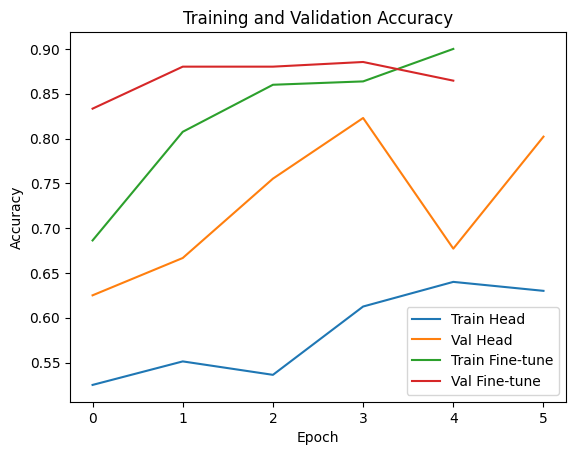

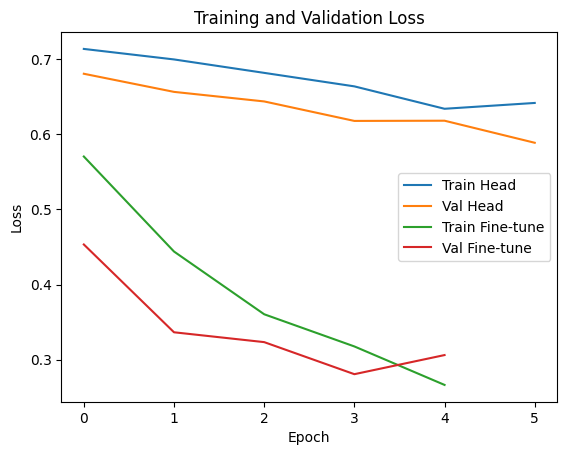

In [17]:
import matplotlib.pyplot as plt

# Accuracy
plt.plot(history_head.history['accuracy'], label='Train Head')
plt.plot(history_head.history['val_accuracy'], label='Val Head')
plt.plot(history_finetune.history['accuracy'], label='Train Fine-tune')
plt.plot(history_finetune.history['val_accuracy'], label='Val Fine-tune')
plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

# Loss
plt.plot(history_head.history['loss'], label='Train Head')
plt.plot(history_head.history['val_loss'], label='Val Head')
plt.plot(history_finetune.history['loss'], label='Train Fine-tune')
plt.plot(history_finetune.history['val_loss'], label='Val Fine-tune')
plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()


In [18]:
import random

# Pick 5 random images from validation set
val_images = []
val_labels = []

for label, folder in enumerate(['cats', 'dogs']):
    folder_path = os.path.join('/kaggle/working/cats_and_dogs_mini', folder)
    files = os.listdir(folder_path)
    val_images.extend([os.path.join(folder_path, f) for f in random.sample(files, 2)])
    val_labels.extend([label]*2)

# Predict and display
for img_path, true_label in zip(val_images, val_labels):
    pred = model.predict(np.expand_dims(image.img_to_array(image.load_img(img_path, target_size=(224,224)))/255.0, axis=0))
    pred_label = 1 if pred[0][0] > 0.5 else 0
    print(f"Image: {os.path.basename(img_path)}, True: {['Cat','Dog'][true_label]}, Predicted: {['Cat','Dog'][pred_label]}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
Image: cat.4211.jpg, True: Cat, Predicted: Dog
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
Image: cat.4236.jpg, True: Cat, Predicted: Cat
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
Image: dog.4336.jpg, True: Dog, Predicted: Dog
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
Image: dog.4074.jpg, True: Dog, Predicted: Dog
